In [10]:
import numpy as np

from scipy.spatial.transform import Rotation

from tracing.tracer import Tracer

from optics.source import Source
from optics.mirror import Mirror
from optics.detector import Detector
from optics.beamsplitter import BeamSplitter

from plotting.views import (
    plot_system,
)


===== RAY SUMMARY =====
000 L=106.574296 n=1.0000 OPL=106.574296
001 L=93.785381 n=1.0000 OPL=93.785381
002 L=83.168168 n=1.0000 OPL=83.168168

Total geometric length : 283.527844
Total optical length : 283.527844
Phase : 2.815199e+09


(<Figure size 800x600 with 1 Axes>, <Axes: >)

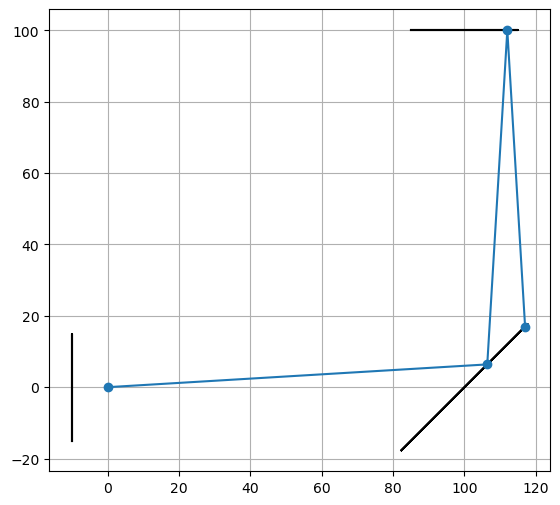

In [13]:
tracer = Tracer()

mirror = Mirror(
    name="M1",

    position=[100, 0, 100],

    rotation=Rotation.identity(),

    width=30,
    height=30,
)

bs = BeamSplitter(
    mode="reflection",
    position=[100,0,0],
    rotation=Rotation.from_euler(
        "y",
        -45,
        degrees=True
    ),
)

detector = Detector(
    name="DET",

    position=[-10, 0, 0],

    rotation=Rotation.from_euler(
        "y",
        -90,
        degrees=True
    ),

    width=30,
    height=30,
)

tracer.add_element(bs)
tracer.add_element(mirror)
tracer.add_element(detector)


source = Source(
    position=[0, 0, 0],
    direction=[1, 0, 0.06],
    wavelength=632.8e-9,
)
ray = source.emit()
ray = tracer.trace(ray)
ray.summary()

plot_system(
    tracer,
    ray,
    view="xz",
)